# Predict delivery time in minutes
This regression model is designed for predicting food delivery times based on various influencing factors such as distance, weather, traffic conditions, and time of day

In [11]:
# import data and necessary libraries
import pandas as pd

df = pd.read_csv("../data/processed/food_delivery_final.csv")

df.head()


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score,customer_rating_missing,delivery_partner_rating_missing,delivery_delay_gap,is_peak_hour,cost_per_km,revenue_per_item,is_night_order
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,True,9,71.1,0,0,8,True,1.033680,25.000000,False
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,False,12,100.0,0,0,-6,True,0.478539,14.285714,True
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,False,10,34.4,0,0,10,False,0.259148,8.333333,False
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,True,1,45.0,0,0,0,False,0.428897,20.730492,False
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,False,6,25.1,0,0,7,True,0.441618,50.000000,False


In [12]:
corr = df.corr(numeric_only=True)['delivery_time_minutes'] \
         .sort_values(ascending=False)

print(corr)

delivery_time_minutes                1.000000
estimated_delivery_time              0.970722
delivery_distance_km                 0.863925
preparation_time_minutes             0.394064
delivery_delay_gap                   0.254973
traffic_level_score                  0.163487
delayed_delivery_flag                0.157359
weather_severity_score               0.136230
cancellation_flag                    0.019753
order_hour                           0.015096
refund_flag                          0.014846
delivery_partner_rating_missing      0.010532
customer_rating_missing              0.010532
customer_age                         0.007701
customer_rating                      0.006905
number_of_items                      0.004095
order_month                          0.004002
is_peak_hour                         0.003561
city_tier                            0.003181
delivery_partner_experience_years    0.002989
tip_amount                          -0.000489
delivery_fee                      

In [13]:
corr = df.corr(numeric_only=True)['delivery_time_minutes']

important_features = corr[abs(corr) > 0.1]

print(important_features.sort_values())

delivery_efficiency_score   -0.819238
cost_per_km                 -0.261499
weather_severity_score       0.136230
delayed_delivery_flag        0.157359
traffic_level_score          0.163487
delivery_delay_gap           0.254973
preparation_time_minutes     0.394064
delivery_distance_km         0.863925
estimated_delivery_time      0.970722
delivery_time_minutes        1.000000
Name: delivery_time_minutes, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# features
features = [
    'delivery_distance_km',
    'preparation_time_minutes',
    'traffic_level_score',
    'weather_severity_score',
    'delivery_efficiency_score',
    'delivery_partner_experience_years',
]

target = 'delivery_time_minutes'

X = df[features]
y = df[target]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression
MAE  : 0.42
RMSE : 1.41
R²   : 0.9983


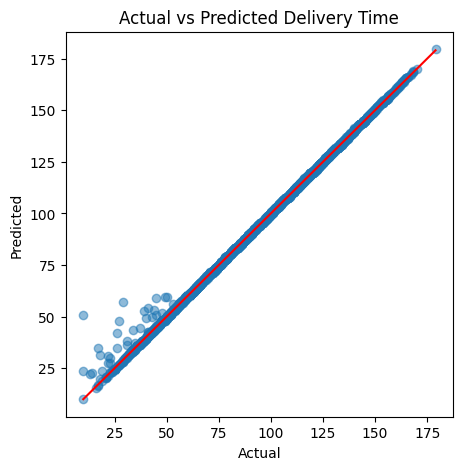

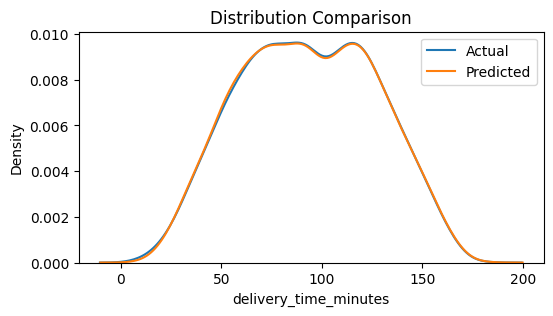

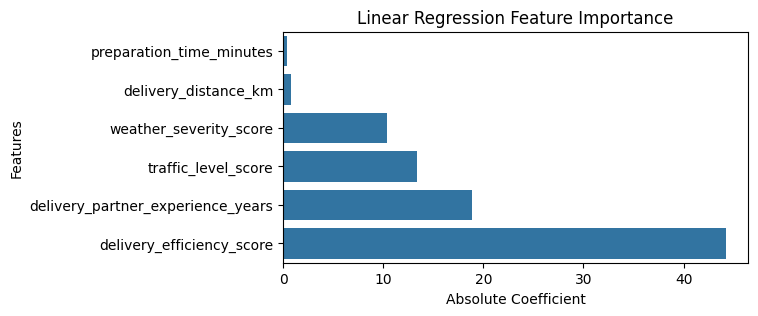

In [15]:
# model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# predictions
y_pred = lr.predict(X_test_scaled)

# evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("Linear Regression")
print("=" * 50)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# Actual vs Predicted
plt.figure(figsize=(5,5))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted Delivery Time")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()



# Distribution comparison
plt.figure(figsize=(6,3))

sns.kdeplot(y_test, label='Actual')
sns.kdeplot(y_pred, label='Predicted')

plt.title("Distribution Comparison")
plt.legend()
plt.show()



# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_
})

importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Abs_Coefficient', ascending=True)

plt.figure(figsize=(6,3))

sns.barplot(
    x='Abs_Coefficient',
    y='Feature',
    data=importance
)

plt.title('Linear Regression Feature Importance')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Features')

plt.show()

Random Forest Results
MAE  : 4.47
RMSE : 5.63
R²   : 0.9721


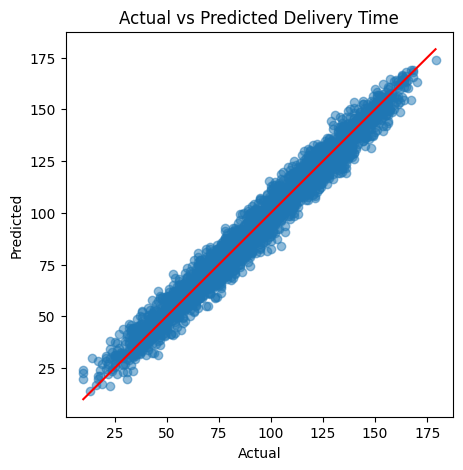

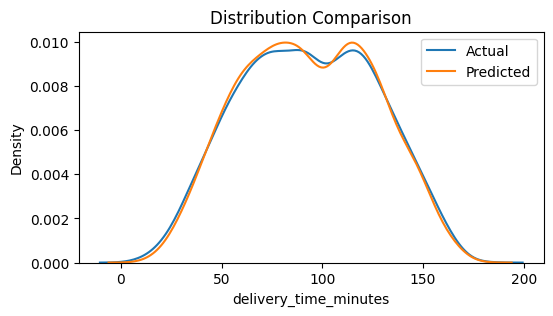

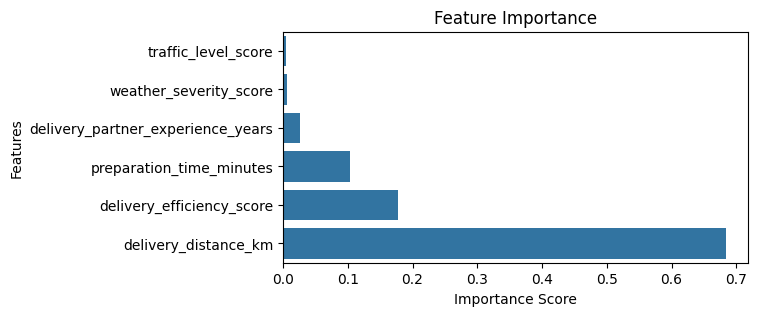

In [16]:
# implementing random forest regression
from sklearn.ensemble import RandomForestRegressor

# model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# training
rf.fit(X_train_scaled, y_train)

# predictions
y_pred = rf.predict(X_test_scaled)

# evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("Random Forest Results")
print("=" * 50)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# actual vs predicted delivery time plot
plt.figure(figsize=(5,5))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted Delivery Time")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Distribution: Actual vs Predicted
plt.figure(figsize=(6,3))

sns.kdeplot(y_test, label='Actual')
sns.kdeplot(y_pred, label='Predicted')

plt.title("Distribution Comparison")
plt.legend()
plt.show()

# importance from model (rf or xgb)
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_   # change to xgb.feature_importances_ if needed
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(6,3))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

XGBoost Results
MAE  : 3.41
RMSE : 4.28
R²   : 0.9839


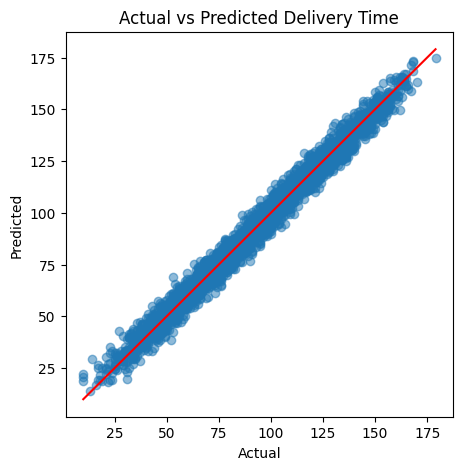

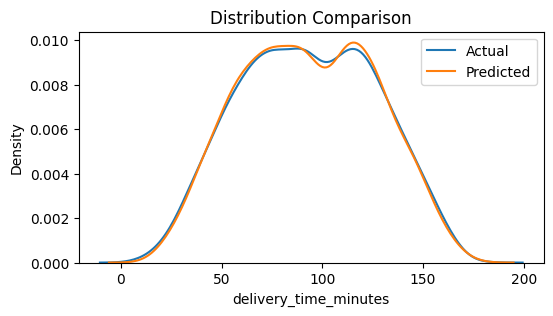

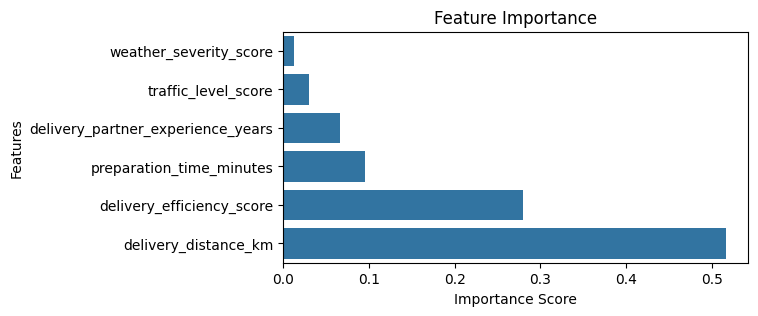

In [17]:
# implementing XGBoost regression
from xgboost import XGBRegressor

# model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# training
xgb.fit(X_train_scaled, y_train)

# predictions
y_pred = xgb.predict(X_test_scaled)

# evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("XGBoost Results")
print("=" * 50)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# actual vs predicted delivery time plot
plt.figure(figsize=(5,5))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted Delivery Time")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Distribution: Actual vs Predicted
plt.figure(figsize=(6,3))

sns.kdeplot(y_test, label='Actual')
sns.kdeplot(y_pred, label='Predicted')

plt.title("Distribution Comparison")
plt.legend()
plt.show()

# importance from model (rf or xgb)
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_   # change to xgb.feature_importances_ if needed
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(6,3))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

In [18]:
# save the best model (linear regression in this case) package including model, scaler, features 
import joblib

joblib.dump({
    "model": lr,
    "scaler": scaler,
    "features": features,
    "X_test": X_test,
    "y_test": y_test
}, "../models/regression_model_package.pkl")



# --- LATER USE ---

# package = joblib.load("../model/regression_model_package.pkl")

# model = package["model"]
# scaler = package["scaler"]
# features = package["features"]

# new_data = {
#     'delivery_distance_km': 5.2,
#     'preparation_time_minutes': 12,
#     'traffic_level_score': 70,
#     'weather_severity_score': 30,
#     'delivery_efficiency_score': 0.8,
#     'delivery_partner_experience_years': 3
# }

# X_new = pd.DataFrame([new_data])

# X_new = X_new[features]

# X_new_scaled = scaler.transform(X_new)

# prediction = model.predict(X_new_scaled)

# print("Predicted delivery time:", prediction[0])

['../models/regression_model_package.pkl']